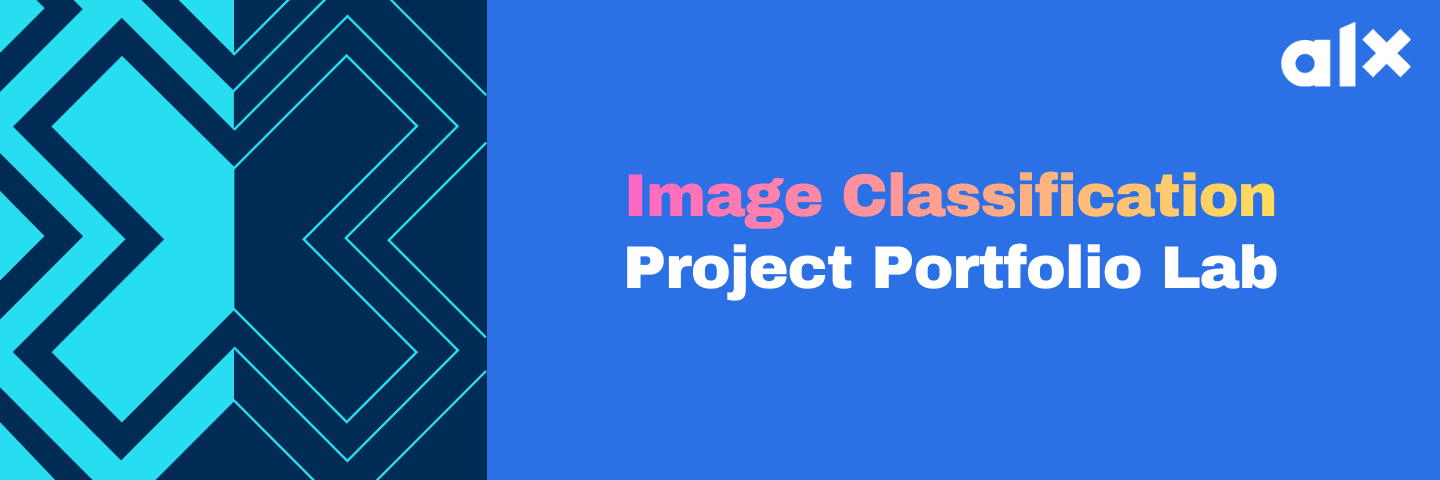

**© 2025 ALX**

# Outcome
By the end of this session, the participant should
- Understand decision trees, random forest and other classification models
- Apply these models for image classification

# Outline
- Decision tree
- Random forest
- Support vector machines (SVM)
- Nearest neighbour (NN)
- Naive Bayes (NB)

# Decision trees

A **decision tree** is a supervised machine learning model used for **classification** and **regression** tasks. It represents decisions and their possible consequences in a tree-like structure, where data is repeatedly split based on feature values to reach a final prediction.

## What a Decision Tree Is

A decision tree consists of the following core components:

* **Root node**
  The starting point of the tree, representing the entire dataset.

* **Decision (internal) nodes**
  Nodes where the data is split based on a condition on a feature (for example, *Age ≤ 30*).

* **Branches**
  Outcomes of a decision rule that lead to another node.

* **Leaf (terminal) nodes**
  Nodes that produce the final output:

  * A **class label** (classification)
  * A **numerical value** (regression)

Each path from the root to a leaf corresponds to a sequence of decisions that form a rule.



<img src="https://almablog-media.s3.ap-south-1.amazonaws.com/image_17_ef951c96c2.png" width="400">


## How a Decision Tree Works

1. **Select the best feature to split the data**
   The algorithm evaluates all features and chooses the one that best separates the data based on a splitting criterion:

   * **Classification**: Gini Impurity, Entropy (Information Gain)
   * **Regression**: Mean Squared Error (MSE), Mean Absolute Error (MAE)

2. **Split the dataset**
   The dataset is divided into subsets according to the chosen feature and threshold.

3. **Repeat recursively**
   The same process is applied to each subset until a stopping condition is met (for example, maximum depth or minimum samples per leaf).

4. **Make predictions**
   For new data, the model follows the decision rules from the root to a leaf and outputs the corresponding prediction.


## Decision Trees in Classification

Used when the target variable is categorical.

Examples:

* Spam vs. non-spam email detection
* Image clasification
* Disease diagnosis (positive / negative)



## Practical Example

**Problem**: Predict whether a customer will buy a product.

**Decision path**:

* Is income > ₦500,000?

  * Yes → Is age < 40?

    * Yes → Buy
    * No → Do not buy
  * No → Do not buy

This sequence of rules is easy to interpret and explain to non-technical stakeholders.



In [1]:
def decide_purchase(income, age):
    if income > 500_000 and age < 40:
      return "Buy"
    else:
        return "Do not buy"

In [2]:
decide_purchase(2000000, 39)

'Buy'

## Advantages of Decision Trees

* Highly **interpretable and explainable**
* Works with **numerical and categorical data**
* Requires minimal data preprocessing
* Captures non-linear relationships

## Limitations of Decision Trees

* Prone to **overfitting** if not properly constrained
* Small data changes can lead to different tree structures
* Generally less accurate than ensemble methods on complex datasets


# Image classification using decision tree algorithm

## Introduction
**Image classification** is a computer vision task in which a machine learning model assigns a predefined label or category to an image based on its visual content. The process typically involves preprocessing images, extracting relevant features (such as color, texture, or shape), and training a model to learn patterns that distinguish one class from another. Modern approaches often use deep learning models, especially convolutional neural networks (CNNs), which automatically learn hierarchical visual features from data.

In real-world applications, image classification is widely used across many domains. In **healthcare**, it helps in diagnosing diseases from medical images such as X-rays and MRI scans. In **agriculture**, it is used to identify plant diseases and classify crops or fruits based on quality. In **security and surveillance**, image classification supports face recognition and threat detection. Other applications include **autonomous vehicles** (road sign recognition), **retail** (product recognition and inventory management), and **social media** (automatic image tagging and content moderation). Overall, image classification enables automated visual understanding, improving efficiency, accuracy, and decision-making in many industries.

## Image Features
Image features/attributes are measurable properties or characteristics of an image that can be used for analysis, processing, or classification.



#### **1. Basic / Low-level Features**

* **Pixel values** – The smallest unit of an image representing the intensity of light at a particular location. In grayscale images, it ranges from 0 (black) to 255 (white). In color images, it has separate values for R, G, B channels.
* **Image dimensions** – The width and height of an image, usually measured in pixels.
* **Aspect ratio** – The ratio of the width to the height of an image or object (width ÷ height).



#### **2. Color-based Features**

* **RGB channels** – Red, Green, and Blue channels that together represent the color of each pixel.
* **HSV channels** – Hue, Saturation, and Value channels; a color space often used because it separates color information (hue) from brightness (value).



#### **3. Shape / Geometric Features**

* **Contours** – Boundaries or outlines of objects in an image, often detected using edge detection algorithms.
* **Edges** – Lines or boundaries where pixel intensity changes sharply, indicating object borders.
* **Corners** – Points where edges meet or intersect, useful for detecting keypoints in an image.
* **Object size** – The total number of pixels belonging to an object.
* **Area** – The measure of the surface covered by an object, usually in pixels or square units.
* **Perimeter** – The length of the boundary of an object.

#### **4. Texture / Pattern Features**

* **GLCM features (contrast, homogeneity, etc.)** – Gray-Level Co-occurrence Matrix features that describe texture patterns:

  * **Contrast**: Measures intensity variations.
  * **Homogeneity**: Measures uniformity of pixel intensities.
* **Local Binary Patterns (LBP)** – Captures local texture by comparing a pixel with its neighbors to form a binary code.
* **Smoothness** – Measures how uniform or rough a surface is in an image.

#### **5. Spatial / Structural Features**

* **Object location** – The coordinates of an object within the image (e.g., center of mass).
* **Relative positions** – How objects are positioned relative to each other.
* **Symmetry** – Degree to which an object is balanced along an axis.
* **Spatial relationships** – Patterns in how objects are arranged or interact spatially in the image.

## About the dataset
We are going to use a subset of the [Kaggle Fruits Dataset](https://www.kaggle.com/datasets/shreyapmaher/fruits-dataset-images) for image classification.   
The dataset contains 360 images of 9 different fruits, namely apple, banana, orange, etc., with each fruit represented by 40 images.

## Installing and import the necessary packages
- Uncomment and install

In [ ]:
#Install Open CV

#pip install opencv-python
#pip install numpy==1.26.4 

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

## Loading the dataset
The Fruits 360 dataset is organized as a `structured folder dataset`. Before feeding the data into a decision tree model, we need to perform feature engineering to convert the images into a tabular format.

In many machine learning models, raw pixel values can be used directly as input features. However, Decision Tree models do not perform well with raw pixels because image data is high-dimensional and spatially structured. To address this limitation, we instead extract meaningful, low-dimensional features—such as summary statistics of the colour channels—as shown in the table below.


| Feature      | Description              |
| ------------ | ------------------------ |
| mean_r       | Average red channel      |
| mean_g       | Average green channel    |
| mean_b       | Average blue channel     |
| std_r        | Red channel variation    |
| std_g        | Green channel variation  |
| std_b        | Blue channel variation   |
| brightness   | Mean grayscale intensity |
| aspect_ratio | Width ÷ Height           |



In [85]:
img = cv2.imread("fruits/Apple fruit/Image_1.jpg") #load image

In [87]:
img

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [89]:
cv2.imshow("apple", img) #show image

In [91]:
img.shape

(1749, 1500, 3)

**We can create a function that will extract the above features.**

In [93]:
def extract_features(image_path):
    img = cv2.imread(image_path)

    # Compute aspect ratio
    h, w = img.shape[:2]
    aspect_ratio = w / h

    # Resize image for consistent feature extraction
    img_resized = cv2.resize(img, (100, 100))

    b, g, r = cv2.split(img_resized)

    features = {
        "mean_r": np.mean(r),
        "mean_g": np.mean(g),
        "mean_b": np.mean(b),
        "std_r": np.std(r),
        "std_g": np.std(g),
        "std_b": np.std(b),
        "brightness": np.mean(cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)),
        "aspect_ratio": aspect_ratio
    }

    return features


**Load the dataset**

In [95]:
dataset_path = "fruits"
data = []

for label in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, label)
    if not os.path.isdir(class_dir):
        continue

    for file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, file)
        features = extract_features(img_path)
        features["label"] = label
        data.append(features)

df = pd.DataFrame(data)
df.head()


libpng warning: iCCP: known incorrect sRGB profile


,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness,aspect_ratio,label
0,226.6137,216.3597,168.9659,40.485324,43.138587,91.039731,214.0354,1.333333,banana fruit
1,226.6752,206.7546,160.8086,36.355887,54.325344,99.570372,207.4805,1.904762,banana fruit
2,98.7166,71.1086,42.6551,62.541061,50.129744,28.641528,76.1172,1.530612,banana fruit
3,145.9306,150.6243,48.0765,72.945545,64.418339,68.804172,137.5313,1.500938,banana fruit
4,241.4282,228.0673,177.9302,28.298647,36.963563,88.565679,226.3494,1.507092,banana fruit


In [97]:
df

,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness,aspect_ratio,label
0,226.6137,216.3597,168.9659,40.485324,43.138587,91.039731,214.0354,1.333333,banana fruit
1,226.6752,206.7546,160.8086,36.355887,54.325344,99.570372,207.4805,1.904762,banana fruit
2,98.7166,71.1086,42.6551,62.541061,50.129744,28.641528,76.1172,1.530612,banana fruit
3,145.9306,150.6243,48.0765,72.945545,64.418339,68.804172,137.5313,1.500938,banana fruit
4,241.4282,228.0673,177.9302,28.298647,36.963563,88.565679,226.3494,1.507092,banana fruit
...,...,...,...,...,...,...,...,...,...
75,94.0310,40.1976,33.7165,80.521617,50.085287,48.633813,55.5638,1.500000,apple fruit
76,202.6105,211.8483,153.1853,61.657248,54.053669,110.726560,202.3964,1.753294,apple fruit
77,234.6363,214.5959,211.8870,39.409172,78.155710,81.968764,220.2839,1.779359,apple fruit
78,198.1857,148.4639,150.0205,58.532222,108.188783,104.155100,163.5007,1.160000,apple fruit


**Check the distribution of the label**

In [99]:
df['label'].value_counts()

label
banana fruit    40
apple fruit     40
Name: count, dtype: int64

- The dataset is balanced.

**Splitting the dataset**

In [101]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**Train the decision tree model**

In [103]:
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42)

**Evaluate the model**

In [105]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.625
              precision    recall  f1-score   support

 apple fruit       0.58      0.88      0.70         8
banana fruit       0.75      0.38      0.50         8

    accuracy                           0.62        16
   macro avg       0.67      0.62      0.60        16
weighted avg       0.67      0.62      0.60        16



**Test our model with a real external fruit images.**

In [119]:
new_image_path = "banana.avif"

features = extract_features(new_image_path)

# Convert to DataFrame with correct column order
X_new = pd.DataFrame([features])


In [121]:
prediction = dt.predict(X_new)
prediction_proba = dt.predict_proba(X_new)

print("Predicted class:", prediction[0])
print("Class probabilities:", prediction_proba)


Predicted class: apple fruit
Class probabilities: [[1. 0.]]


## Random Forest

![Image](https://miro.medium.com/1%2Ai0o8mjFfCn-uD79-F1Cqkw.png?)

**Random Forest** is an ensemble machine learning algorithm used for **classification** and **regression**. It operates by constructing a large number of decision trees during training and combining their predictions to produce a more accurate and robust final result.

### How It Works

1. **Bootstrap Sampling (Bagging)**
   Multiple training datasets are created by sampling with replacement from the original dataset.

2. **Training Multiple Decision Trees**
   A decision tree is trained on each bootstrap sample.

3. **Feature Randomness**
   At each split in a tree, only a random subset of features is considered. This decorrelates the trees.

4. **Aggregation of Predictions**

   * **Classification:** majority vote across trees
   * **Regression:** average of tree outputs

### Why It Is Effective

* Reduces **overfitting** compared to a single decision tree
* Handles **high-dimensional data** well
* Captures **nonlinear relationships**
* Robust to noise and outliers

### Key Hyperparameters

* `n_estimators`: number of trees in the forest
* `max_depth`: maximum depth of each tree
* `max_features`: number of features considered at each split
* `min_samples_split`: minimum samples required to split a node

### Advantages

* High predictive performance with minimal tuning
* Works well with mixed data types
* Provides **feature importance** estimates

### Limitations

* Less interpretable than a single decision tree
* More computationally expensive
* Larger memory footprint

### Typical Use Cases

* Image and text classification (after feature extraction)
* Fraud detection
* Medical diagnosis
* Tabular business data (e.g., credit scoring)

In practice, Random Forest is often a strong baseline model, especially for structured/tabular datasets where linear models or single trees underperform.


## Laoding the dataset

It is possible to feed the raw pixel values of the images directly into a Random Forest algorithm without performing any feature engineering.

In [123]:
# Path to dataset (update as needed)
dataset_path = "fruits"

# Parameters
image_size = (100, 100)  # resize images to 100x100

X = []
y = []

# Load images
for fruit_class in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, fruit_class)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, image_size)
                X.append(img.flatten())  # flatten to 1D array
                y.append(fruit_class)
            except:
                print(f"Error loading {img_path}")

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape, y.shape)


libpng warning: iCCP: known incorrect sRGB profile


Dataset shape: (80, 30000) (80,)


**Split the dataset into training and testing sets**

In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**Train the Random Forest model**

In [127]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Evaluate the model**

In [129]:
y_pred = rf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print(classification_report(y_test, y_pred))


Accuracy: 0.875
              precision    recall  f1-score   support

 apple fruit       0.80      1.00      0.89         8
banana fruit       1.00      0.75      0.86         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16



In [131]:
def load_and_preprocess_image(image_path, image_size=(100, 100)):
    """
    Loads an image from the given path, converts it to RGB,
    resizes it, and flattens it to a 1D array suitable for Random Forest.
    
    Parameters:
    - image_path: str, path to the image file
    - image_size: tuple, size to resize the image (width, height)
    
    Returns:
    - img_features: np.array of shape (1, num_features)
    """
    try:
        # Load image
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Unable to load image at {image_path}")
        
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize image
        img = cv2.resize(img, image_size)
        
        # Flatten to 1D array and reshape for a single sample
        img_features = img.flatten().reshape(1, -1)
        
        return img_features
    
    except Exception as e:
        print("Error:", e)
        return None


In [139]:
# Preprocess a new image
image_path = "banana.avif"
features = load_and_preprocess_image(image_path)

if features is not None:
    predicted_class = rf.predict(features)
    print("Predicted class:", predicted_class[0])


Predicted class: banana fruit


## Support Vector Machine (SVM)

**Support Vector Machine (SVM)** is a supervised machine learning algorithm used for **classification** and **regression** tasks. It is especially effective for high-dimensional data and cases where the classes are not linearly separable.

### 1. **How SVM Works**

* SVM finds the **optimal hyperplane** that separates classes in the feature space.
* The hyperplane is chosen to **maximize the margin**, which is the distance between the hyperplane and the nearest data points of each class.
* These nearest points are called **support vectors**, and they are critical in defining the decision boundary.

### 2. **Key Concepts**

* **Margin:** Distance between the hyperplane and closest data points from each class.
* **Support Vectors:** Data points that lie closest to the hyperplane; they define the decision boundary.
* **Kernel Trick:** SVM can use **kernels** to handle non-linear separations by mapping data into higher-dimensional space. Common kernels:

  * Linear
  * Polynomial
  * Radial Basis Function (RBF)
  * Sigmoid

### 3. **Advantages**

* Effective in **high-dimensional spaces**.
* Works well when the number of features > number of samples.
* Robust to overfitting, especially with proper regularization.

### 4. **Limitations**

* Computationally expensive for very large datasets.
* Less effective when classes are heavily overlapping.
* Requires careful selection of kernel and hyperparameters.

### 5. **Typical Applications**

* Text classification (spam detection, sentiment analysis)
* Image recognition
* Bioinformatics (e.g., cancer classification)
* Handwriting recognition


SVM is often chosen for **structured datasets** and problems where a clear margin of separation exists. Its performance can be further improved using **feature scaling** and **kernel selection**.
